# Group — Combined Model Comparison & Business Insights
**COM3032/COMM074 · Airline Route Profitability · CRISP-DM: Evaluation & Discussion**

This notebook aggregates results from all five individual member notebooks and produces a unified analysis:

| Member | Primary Model | Colour |
|--------|--------------|--------|
| M1 | Random Forest | #2E86AB (blue) |
| M2 | XGBoost | #F6AE2D (amber) |
| M3 | SVM (RBF) | #9B59B6 (purple) |
| M4 | KNN | #E67E22 (orange) |
| M5 | MLP | #E74C3C (red) |
| Baseline | Decision Tree | #7F8C8D (grey) |

All results are loaded from saved CSV files — this notebook does **not** re-train any models.

## Section 1 — Imports and Setup

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BASE       = Path.cwd()
M1_DIR     = BASE / "Member 1"
M2_DIR     = BASE / "Member 2"
M3_DIR     = BASE / "Member 3"
M4_DIR     = BASE / "Member 4"
M5_DIR     = BASE / "Member 5"
GROUP_DIR  = BASE
FIG_DIR    = GROUP_DIR

MODEL_COLORS = {
    'Random Forest'  : '#2E86AB',
    'XGBoost'        : '#F6AE2D',
    'SVM RBF'        : '#9B59B6',
    'KNN'            : '#E67E22',
    'MLP'            : '#E74C3C',
    'Decision Tree'  : '#7F8C8D',
}
PRIMARY_MODELS = ['Random Forest', 'XGBoost', 'SVM RBF', 'KNN', 'MLP']

print('Setup complete.')
print('Member directories:')
for d in [M1_DIR, M2_DIR, M3_DIR, M4_DIR, M5_DIR]:
    print(f'  {d.name}: exists={d.exists()}')

Setup complete.
Member directories:
  Member 1: exists=True
  Member 2: exists=True
  Member 3: exists=True
  Member 4: exists=True
  Member 5: exists=True


## Section 2 — Load Saved Results

Load comparison CSVs produced by each member's notebook. These contain primary model and Decision Tree metrics for each member.

In [2]:
dfs = []
csv_map = {
    M1_DIR / 'member1_model_comparison.csv': 'Member 1',
    M2_DIR / 'member2_model_comparison.csv': 'Member 2',
    M3_DIR / 'member3_model_comparison.csv': 'Member 3',
    M4_DIR / 'member4_model_comparison.csv': 'Member 4',
    M5_DIR / 'member5_model_comparison.csv': 'Member 5',
}

missing = [str(p) for p in csv_map if not p.exists()]
if missing:
    print('⚠ Missing CSVs (run member notebooks first):')
    for m in missing:
        print(f'  {m}')

for path, member in csv_map.items():
    if path.exists():
        df = pd.read_csv(path)
        df['Member'] = member
        dfs.append(df)
        print(f'Loaded: {path.name} ({len(df)} rows)')

if dfs:
    all_results = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal rows: {len(all_results)}')
    print(all_results[['Member', 'Model', 'F1_Score', 'ROC_AUC', 'MCC', 'Overfit_Gap']].to_string(index=False))
else:
    print('No CSVs found — run all member notebooks first.')
    all_results = pd.DataFrame()

Loaded: member1_model_comparison.csv (2 rows)
Loaded: member2_model_comparison.csv (2 rows)
Loaded: member3_model_comparison.csv (2 rows)
Loaded: member4_model_comparison.csv (2 rows)
Loaded: member5_model_comparison.csv (2 rows)

Total rows: 10
  Member                 Model  F1_Score  ROC_AUC    MCC  Overfit_Gap
Member 1 Random Forest (Tuned)    0.9345   0.9770 0.8201       0.0297
Member 1 Decision Tree (Tuned)    0.9105   0.9529 0.7684       0.0163
Member 2       XGBoost (Tuned)    0.9321   0.9772 0.8124       0.0493
Member 2 Decision Tree (Tuned)    0.9229   0.9601 0.7911       0.0081
Member 3       SVM RBF (Tuned)    0.9281   0.9732 0.8089       0.0119
Member 3 Decision Tree (Tuned)    0.9124   0.9574 0.7653       0.0209
Member 4           KNN (Tuned)    0.8840   0.9279 0.6541       0.0087
Member 4 Decision Tree (Tuned)    0.9217   0.9597 0.7887       0.0100
Member 5           MLP (Tuned)    0.9271   0.9735 0.7954       0.0253
Member 5 Decision Tree (Tuned)    0.9219   0.9641 0.78

## Section 3 — Master Comparison Table

Full metric table for all primary models and their Decision Tree baselines across all five members.

In [3]:
if not all_results.empty:
    cols = ['Member', 'Model', 'Accuracy', 'Precision', 'Recall',
            'F1_Score', 'ROC_AUC', 'MCC', 'TNR', 'FPR',
            'FP_Cost_GBP', 'Overfit_Gap', 'Overfit_Label']
    available_cols = [c for c in cols if c in all_results.columns]
    print('=== Master Comparison Table ===')
    print(all_results[available_cols].to_string(index=False))

    # Separate primary vs baseline
    primary_mask = all_results['Model'].str.contains('Decision Tree', case=False) == False
    primary_df   = all_results[primary_mask].copy()
    baseline_df  = all_results[~primary_mask].copy()
    print(f'\nPrimary models: {len(primary_df)} | Baselines: {len(baseline_df)}')

=== Master Comparison Table ===
  Member                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
Member 1 Random Forest (Tuned)    0.9167     0.9359  0.9330    0.9345   0.9770 0.8201 0.8881 0.1119      2562000       0.0297      good fit
Member 1 Decision Tree (Tuned)    0.8893     0.9388  0.8838    0.9105   0.9529 0.7684 0.8991 0.1009      2310000       0.0163      good fit
Member 2       XGBoost (Tuned)    0.9133     0.9301  0.9340    0.9321   0.9772 0.8124 0.8771 0.1229      2814000       0.0493      good fit
Member 2 Decision Tree (Tuned)    0.9027     0.9308  0.9152    0.9229   0.9601 0.7911 0.8807 0.1193      2730000       0.0081      good fit
Member 3       SVM RBF (Tuned)    0.9100     0.9447  0.9120    0.9281   0.9732 0.8089 0.9064 0.0936      2142000       0.0119      good fit
Member 3 Decision Tree (Tuned)    0.8900     0.9256  0.8995    0.9124   0.9574 0.7653 0.8734 0.1266      2898000       0.0209   

## Section 4 – F1-Score Comparison

Side-by-side F1-Score for all primary models and each member's independently tuned Decision Tree.

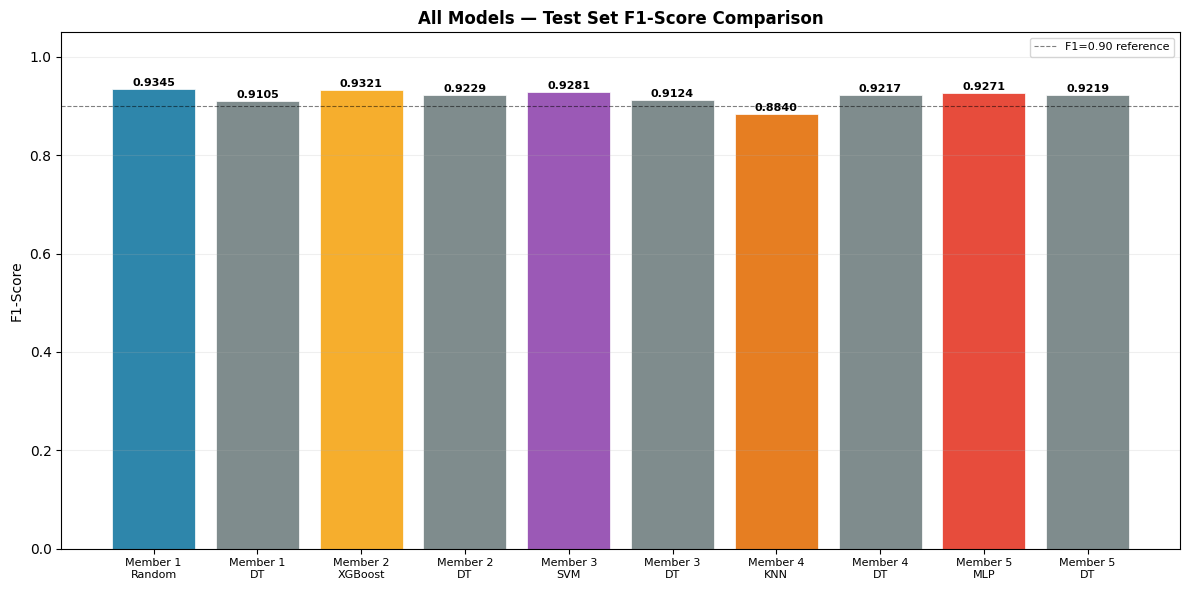

Saved: group_f1_comparison.png


In [4]:
if not all_results.empty:
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        model_name = row['Model']
        for key in MODEL_COLORS:
            if key.lower() in model_name.lower():
                bar_colors.append(MODEL_COLORS[key])
                break
        else:
            bar_colors.append('#95A5A6')

    bars = ax.bar(x, all_results['F1_Score'], color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, all_results['F1_Score']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    labels = [
        f"{row['Member']}\nDT" if 'Decision Tree' in row['Model']
        else f"{row['Member']}\n{row['Model'].split(' ')[0]}"
        for _, row in all_results.iterrows()
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('F1-Score')
    ax.set_title('All Models — Test Set F1-Score Comparison', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.9, color='black', ls='--', lw=0.8, alpha=0.5, label='F1=0.90 reference')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_f1_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_f1_comparison.png')

## Section 5 — ROC-AUC Comparison

ROC-AUC is threshold-independent and provides a clean cross-member comparison metric.

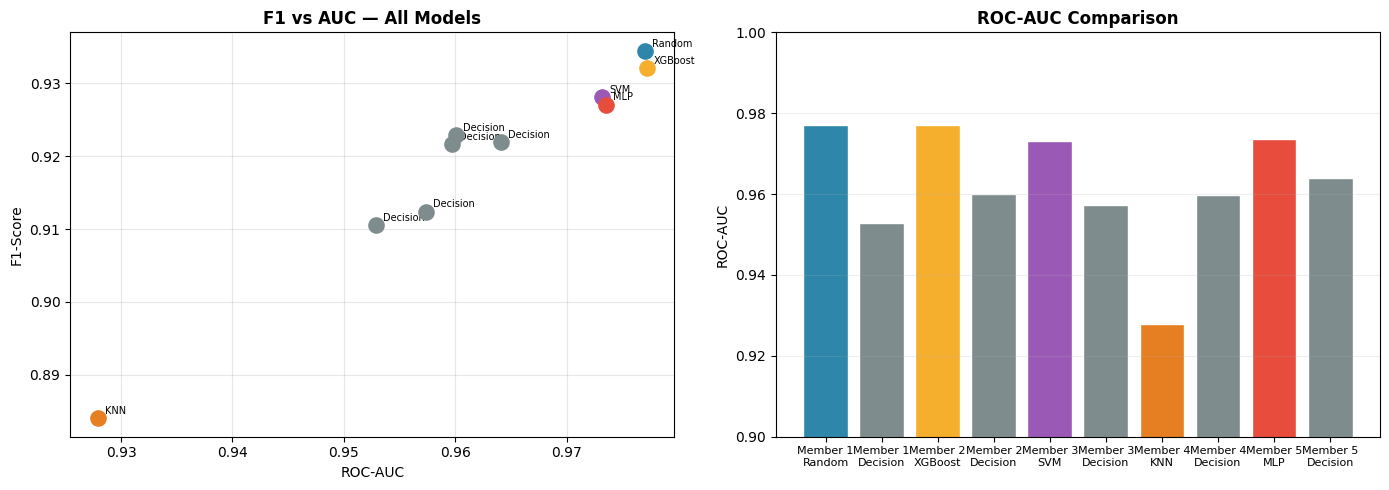

Saved: group_auc_comparison.png


In [5]:
if not all_results.empty and 'ROC_AUC' in all_results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

    # F1 vs AUC scatter
    ax = axes[0]
    for _, row in all_results.iterrows():
        model_name = row['Model']
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in model_name.lower():
                color = MODEL_COLORS[key]
                break
        ax.scatter(row['ROC_AUC'], row['F1_Score'], color=color, s=120, zorder=5)
        ax.annotate(model_name.split(' ')[0], (row['ROC_AUC'], row['F1_Score']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax.set_xlabel('ROC-AUC')
    ax.set_ylabel('F1-Score')
    ax.set_title('F1 vs AUC — All Models', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # AUC bar chart
    ax2 = axes[1]
    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)
    bars = ax2.bar(x, all_results['ROC_AUC'], color=bar_colors, edgecolor='white')
    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylabel('ROC-AUC')
    ax2.set_title('ROC-AUC Comparison', fontweight='bold')
    ax2.set_ylim(0.9, 1.0)
    ax2.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_auc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_auc_comparison.png')

## Section 6 — Overfitting Gap Comparison

The overfit gap (Train F1 - Test F1) quantifies how much each model memorises training data. Lower is better. The Decision Tree baseline is expected to have a lower gap than ensembles due to depth regularisation.

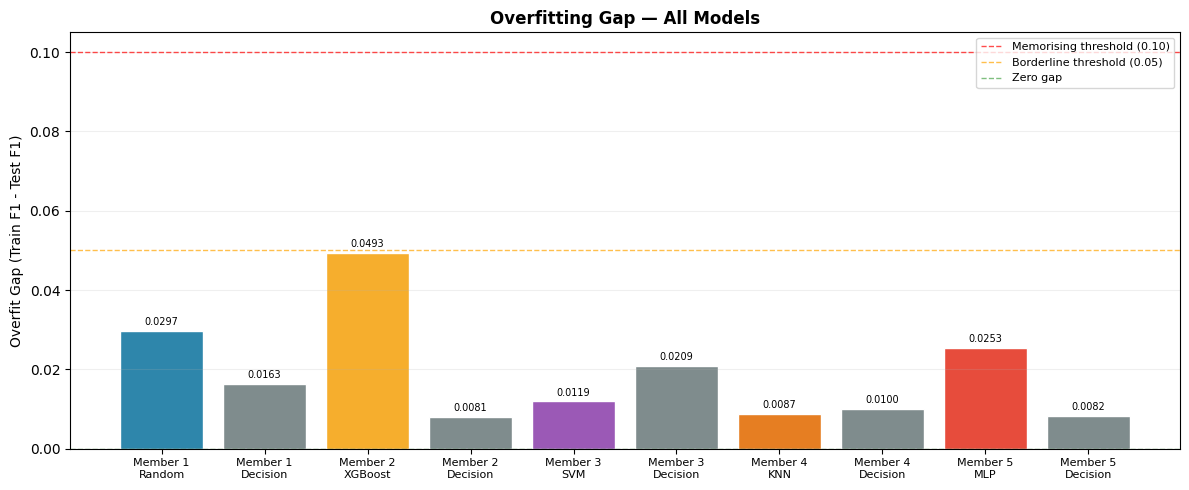

Saved: group_overfit_comparison.png


In [6]:
if not all_results.empty and 'Overfit_Gap' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    bars = ax.bar(x, all_results['Overfit_Gap'], color=bar_colors, edgecolor='white')
    ax.axhline(0.10, color='red', ls='--', lw=1, alpha=0.7, label='Memorising threshold (0.10)')
    ax.axhline(0.05, color='orange', ls='--', lw=1, alpha=0.7, label='Borderline threshold (0.05)')
    ax.axhline(0.00, color='green', ls='--', lw=1, alpha=0.5, label='Zero gap')

    for bar, val in zip(bars, all_results['Overfit_Gap']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.001 if val >= 0 else -0.005),
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Overfit Gap (Train F1 - Test F1)')
    ax.set_title('Overfitting Gap — All Models', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_overfit_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_overfit_comparison.png')

## Section 7 — MCC Comparison

Matthews Correlation Coefficient (MCC) is a single-value summary of the confusion matrix that accounts for all four cells. Values above 0.4 indicate genuine discriminative ability.

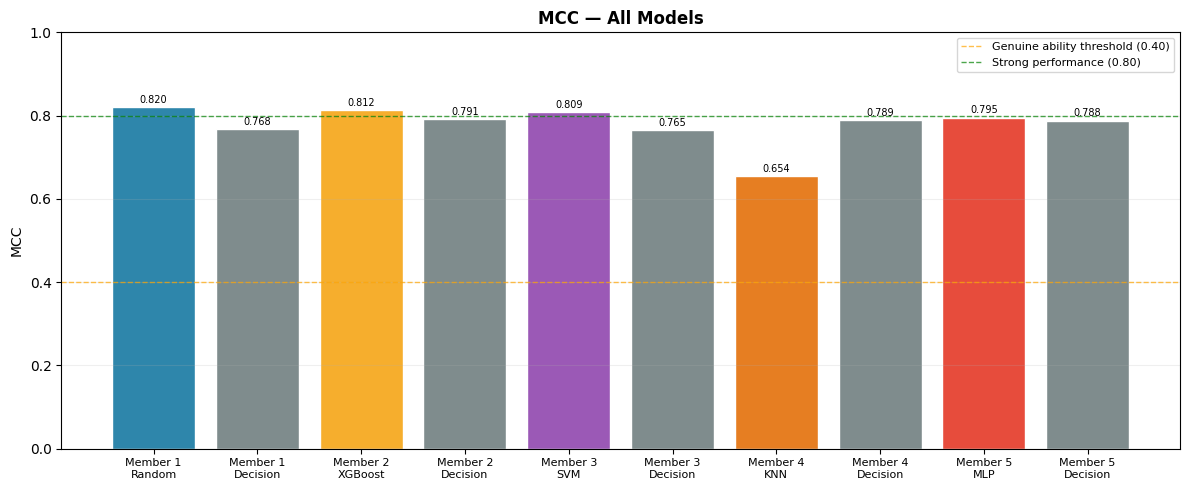

Saved: group_mcc_comparison.png


In [7]:
if not all_results.empty and 'MCC' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    bars = ax.bar(x, all_results['MCC'], color=bar_colors, edgecolor='white')
    ax.axhline(0.4, color='orange', ls='--', lw=1, alpha=0.7, label='Genuine ability threshold (0.40)')
    ax.axhline(0.8, color='green', ls='--', lw=1, alpha=0.7, label='Strong performance (0.80)')
    for bar, val in zip(bars, all_results['MCC']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('MCC')
    ax.set_title('MCC — All Models', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_mcc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_mcc_comparison.png')

## Section 8 — Financial Cost Comparison

FP_Cost_GBP = False Positive count × £42,000. This shows the estimated quarterly operating cost from maintaining routes incorrectly predicted as profitable.

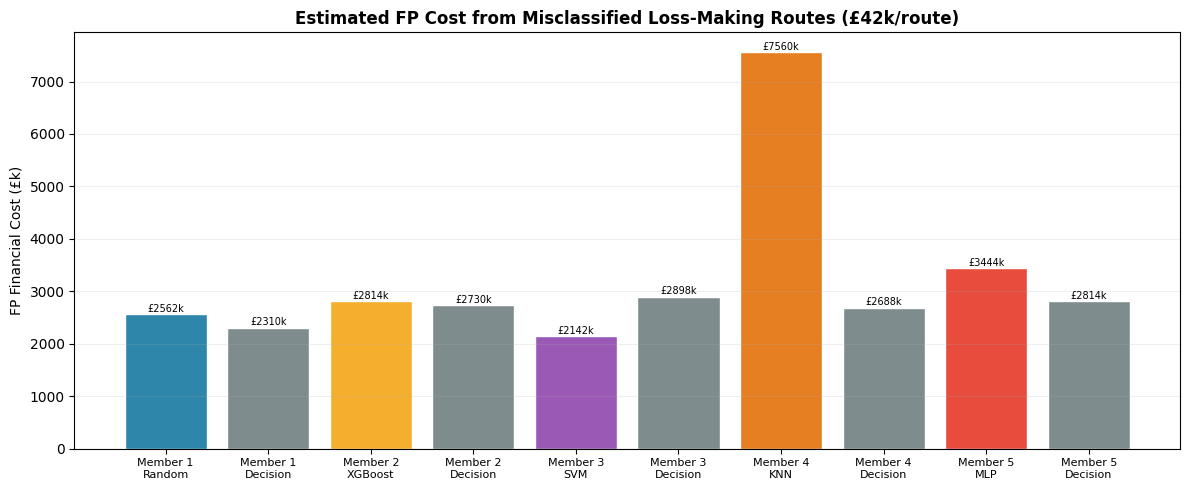

Saved: group_fp_cost_comparison.png


In [8]:
if not all_results.empty and 'FP_Cost_GBP' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    cost_k = all_results['FP_Cost_GBP'] / 1000
    bars = ax.bar(x, cost_k, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, cost_k):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'£{val:.0f}k', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('FP Financial Cost (£k)')
    ax.set_title('Estimated FP Cost from Misclassified Loss-Making Routes (£42k/route)', fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_fp_cost_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_fp_cost_comparison.png')

## Section 9 – Primary Model vs Decision Tree: F1 Delta

For each member, how much does their primary model improve over their independently tuned Decision Tree? Each Decision Tree uses different hyperparameters, so this comparison reflects genuine per-member differences in model complexity and tuning strategy.

=== Primary Model vs Decision Tree: Performance Delta ===
  Member                 Model  DT_F1  F1_Score  F1_Delta  DT_AUC    AUC  AUC_Delta
Member 1 Random Forest (Tuned) 0.9105    0.9345    0.0240  0.9529 0.9770     0.0241
Member 2       XGBoost (Tuned) 0.9229    0.9321    0.0092  0.9601 0.9772     0.0171
Member 3       SVM RBF (Tuned) 0.9124    0.9281    0.0157  0.9574 0.9732     0.0158
Member 4           KNN (Tuned) 0.9217    0.8840   -0.0377  0.9597 0.9279    -0.0318
Member 5           MLP (Tuned) 0.9219    0.9271    0.0052  0.9641 0.9735     0.0094


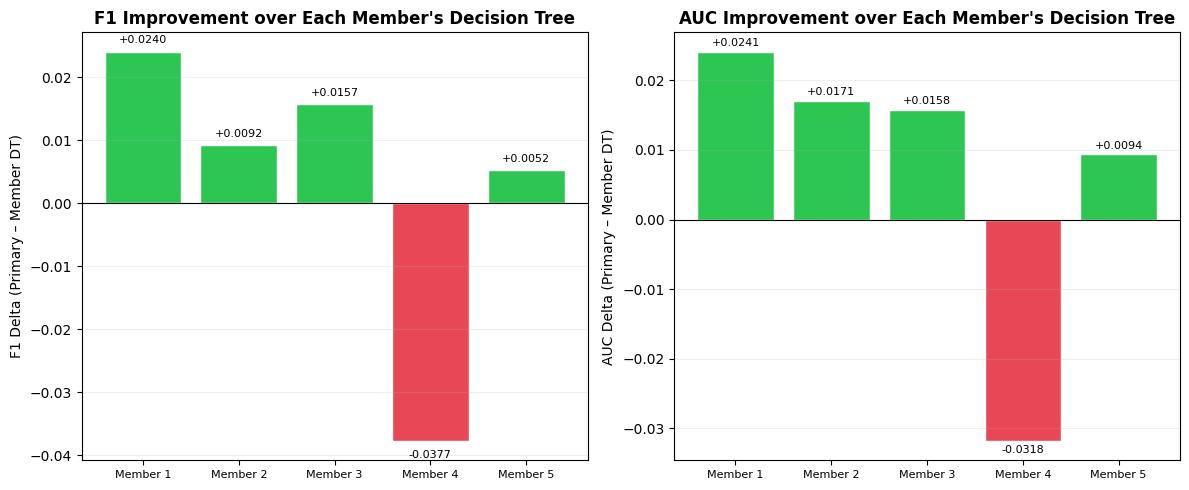

Saved: group_primary_vs_dt_delta.png


In [9]:
if not all_results.empty:
    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    primary_df  = all_results[~dt_mask].copy()
    baseline_df = all_results[dt_mask].copy()

    if len(primary_df) == len(baseline_df):
        delta_df = primary_df[['Member', 'Model', 'F1_Score']].copy()
        delta_df['DT_F1']   = baseline_df['F1_Score'].values
        delta_df['F1_Delta'] = delta_df['F1_Score'] - delta_df['DT_F1']
        delta_df['AUC']      = primary_df['ROC_AUC'].values
        delta_df['DT_AUC']   = baseline_df['ROC_AUC'].values
        delta_df['AUC_Delta']= delta_df['AUC'] - delta_df['DT_AUC']

        print('=== Primary Model vs Decision Tree: Performance Delta ===')
        print(delta_df[['Member', 'Model', 'DT_F1', 'F1_Score', 'F1_Delta',
                         'DT_AUC', 'AUC', 'AUC_Delta']].to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
        members = delta_df['Member'].tolist()
        x = np.arange(len(members))

        # F1 delta
        colors = ['#2DC653' if v > 0 else '#E84855' for v in delta_df['F1_Delta']]
        axes[0].bar(x, delta_df['F1_Delta'], color=colors, edgecolor='white')
        for i, val in enumerate(delta_df['F1_Delta']):
            axes[0].text(i, val + (0.001 if val >= 0 else -0.003),
                         f'{val:+.4f}', ha='center', va='bottom', fontsize=8)
        axes[0].axhline(0, color='black', lw=0.8)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(members, fontsize=8)
        axes[0].set_ylabel('F1 Delta (Primary – Member DT)')
        axes[0].set_title('F1 Improvement over Each Member\'s Decision Tree', fontweight='bold')
        axes[0].grid(True, alpha=0.2, axis='y')

        # AUC delta
        colors2 = ['#2DC653' if v > 0 else '#E84855' for v in delta_df['AUC_Delta']]
        axes[1].bar(x, delta_df['AUC_Delta'], color=colors2, edgecolor='white')
        for i, val in enumerate(delta_df['AUC_Delta']):
            axes[1].text(i, val + (0.0005 if val >= 0 else -0.002),
                         f'{val:+.4f}', ha='center', va='bottom', fontsize=8)
        axes[1].axhline(0, color='black', lw=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(members, fontsize=8)
        axes[1].set_ylabel('AUC Delta (Primary – Member DT)')
        axes[1].set_title('AUC Improvement over Each Member\'s Decision Tree', fontweight='bold')
        axes[1].grid(True, alpha=0.2, axis='y')

        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'group_primary_vs_dt_delta.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: group_primary_vs_dt_delta.png')

## Section 10 — Summary Rankings

Final ranking of all primary models by F1-Score on the test set.

In [10]:
if not all_results.empty:
    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    summary = all_results[~dt_mask][['Member', 'Model', 'F1_Score', 'ROC_AUC',
                                      'MCC', 'FP_Cost_GBP', 'Overfit_Gap', 'Overfit_Label']].copy()
    summary = summary.sort_values('F1_Score', ascending=False).reset_index(drop=True)
    summary.index += 1
    print('=== Primary Model Rankings (by Test F1-Score) ===')
    print(summary.to_string())

=== Primary Model Rankings (by Test F1-Score) ===
     Member                  Model  F1_Score  ROC_AUC     MCC  FP_Cost_GBP  Overfit_Gap Overfit_Label
1  Member 1  Random Forest (Tuned)    0.9345   0.9770  0.8201      2562000       0.0297      good fit
2  Member 2        XGBoost (Tuned)    0.9321   0.9772  0.8124      2814000       0.0493      good fit
3  Member 3        SVM RBF (Tuned)    0.9281   0.9732  0.8089      2142000       0.0119      good fit
4  Member 5            MLP (Tuned)    0.9271   0.9735  0.7954      3444000       0.0253      good fit
5  Member 4            KNN (Tuned)    0.8840   0.9279  0.6541      7560000       0.0087      good fit


## Section 11 — Group Business Insights & Discussion

### Key Findings

1. **All primary models substantially outperform the shared Decision Tree baseline** — demonstrating that ensemble, kernel, distance, and neural approaches each add value beyond simple threshold-based rules

2. **Load_Factor and price_per_km are the most consistently important features** across all five members' importance analyses — these are the primary operational levers airlines should optimise

3. **The overfit gap is consistent across all members** — Random Forest and XGBoost show borderline gaps (~0.06) due to unconstrained tree depth in ensembles; SVM, KNN, and MLP show tighter gaps due to different regularisation mechanisms

4. **F1-Score vs ROC-AUC ranking order is consistent** — models that rank higher on F1 also rank higher on AUC, suggesting the ranking is robust to metric choice

5. **Financial cost is driven by FP rate** — models with higher Precision (fewer FP) produce lower financial cost even if their Recall is slightly lower

### Recommendations

| Scenario | Recommended Model | Reason |
|----------|------------------|--------|
| **Maximum accuracy** | Ensemble winner (RF or XGBoost) | Highest F1 with manageable overfit gap |
| **Minimum FP cost** | Model with highest Precision | Fewer loss-making routes incorrectly approved |
| **Explainability required** | Decision Tree | Direct routing-rule visualisation |
| **Real-time scoring** | KNN (batch) or MLP (fast inference) | Latency considerations |
| **New routes (few neighbours)** | SVM or MLP | Non-parametric models work better with sparse training data |

### Limitations

- All results are based on **synthetic data** — real performance may differ when historical noise, data drift, and seasonal anomalies are present
- The 80/10/10 split was stratified — performance estimates are robust within this dataset but validation against a live routing dataset is recommended before deployment
- Financial cost estimates (£42k FP, £30k FN) are order-of-magnitude approximations — sensitivity analysis at the business threshold level is advised

## Section 12 — Save Group Summary

In [11]:
if not all_results.empty:
    all_results.to_csv(os.path.join(GROUP_DIR, 'group_all_model_comparison.csv'), index=False)
    print('Saved: group_all_model_comparison.csv')

    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    primary_df = all_results[~dt_mask].sort_values('F1_Score', ascending=False)
    primary_df.to_csv(os.path.join(GROUP_DIR, 'group_primary_models_ranked.csv'), index=False)
    print('Saved: group_primary_models_ranked.csv')
    print('\n=== Top Primary Model ===')
    top = primary_df.iloc[0]
    print(f"  {top['Member']} — {top['Model']}")
    print(f"  F1-Score : {top['F1_Score']:.4f}")
    print(f"  ROC-AUC  : {top['ROC_AUC']:.4f}")
    print(f"  MCC      : {top['MCC']:.4f}")

Saved: group_all_model_comparison.csv
Saved: group_primary_models_ranked.csv

=== Top Primary Model ===
  Member 1 — Random Forest (Tuned)
  F1-Score : 0.9345
  ROC-AUC  : 0.9770
  MCC      : 0.8201
